In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob

In [2]:
#SimEvent.energyTrue è l'energia nominale simulata su hawcsim
#rec.LHLatDistFitEnergy è l'energia ricostruita da swgo_reco

In [3]:
E_reco_gamma = []
E_true_gamma = []
PE_gamma_calibrated_list = []
N_tank_hit_gamma = []
PE_true_list = []

reco_repo = Path("/home/grieco/multiPMT_reco/Gamma_reco/4FF_R600m_h175r180_black_uniform0600m_100300TeV_030deg")

for file in reco_repo.glob("*.root"):
            name = file.stem 
            #print("Processing File", name + ".root")
            DAT = uproot.open(file)
            tree = DAT["XCDF"]
            df = tree.arrays(library = "pd")
            for j in range(1,len(df["event.eventID"]) +  1):
                gamma = df[df["event.eventID"] == j] 
                True_Energy = np.asarray(gamma["SimEvent.energyTrue"].iloc[0])
                Reco_Energy = np.asarray(gamma["rec.LHLatDistFitEnergy"].iloc[0])
                PE_gamma_calibrated = np.asarray(gamma["event.sumPE"].iloc[0])
                PE_True = np.asarray(gamma["SimEvent.nPE"].iloc[0])
                
                True_Energy_log = np.log10((True_Energy))

                Reco_Energy_log = ((Reco_Energy))
                E_true_gamma.append(True_Energy_log)
                E_reco_gamma.append(Reco_Energy_log)
                PE_gamma_calibrated_list.append(PE_gamma_calibrated)
                PE_true_list.append(PE_True)

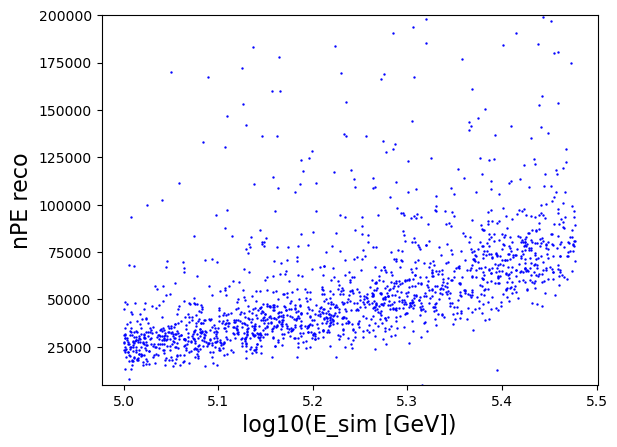

In [4]:
plt.scatter(E_true_gamma, PE_gamma_calibrated_list, marker = ".", s = 2, color = "blue")
plt.xlabel("log10(E_sim [GeV])", fontsize = 16)
plt.ylabel("nPE reco", fontsize = 16)
plt.ylim(0.5e4,2e5)
plt.show()

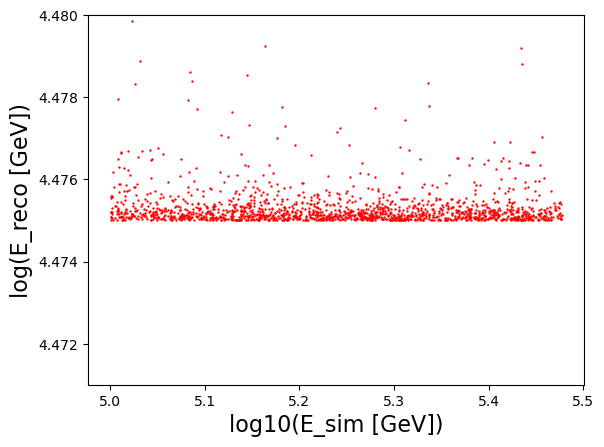

In [5]:
plt.scatter(E_true_gamma, E_reco_gamma, marker = ".", s = 2, color = "red")
plt.xlabel("log10(E_sim [GeV])", fontsize = 16)
plt.ylabel("log(E_reco [GeV])", fontsize = 16)
plt.ylim(4.471,4.48)
#plt.savefig("pictures/other/swgo_recoMPMT.png", dpi = 300)
plt.show()

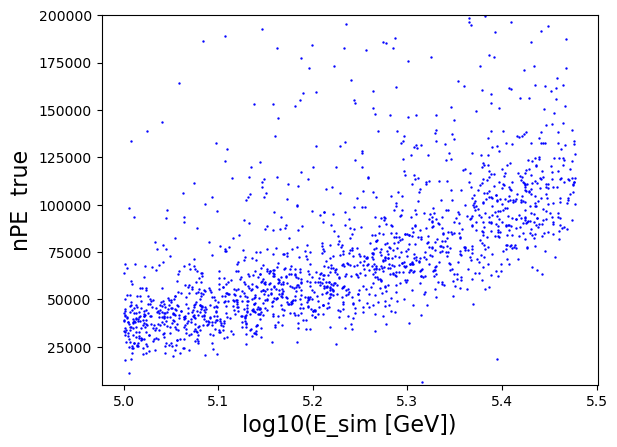

In [6]:
plt.scatter(E_true_gamma, PE_true_list, marker = ".", s = 2, color = "blue")
plt.xlabel("log10(E_sim [GeV])", fontsize = 16)
plt.ylabel("nPE  true", fontsize = 16)
plt.ylim(0.5e4,2e5)
plt.show()

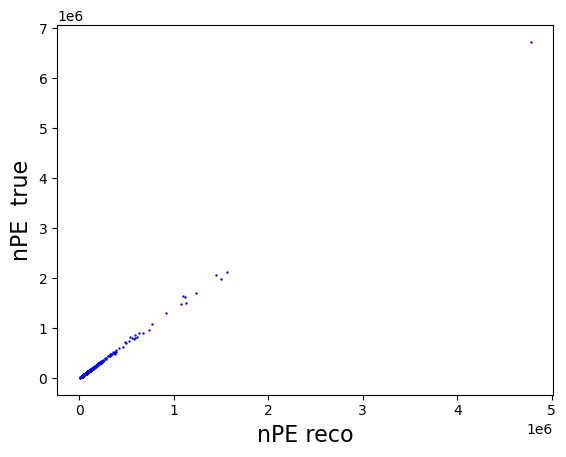

In [7]:
plt.scatter(PE_gamma_calibrated_list, PE_true_list, marker = ".", s = 2, color = "blue")
plt.xlabel("nPE reco", fontsize = 16)
plt.ylabel("nPE  true", fontsize = 16)
#plt.ylim(0.5e4,2e5)
plt.show()